# CGC + Chiller Test

This test is for testing the water supply from the chiller to all water cooled cgc devices.
Devices used: PSU 1-4, SwitchA and SwitchB, Lauda CGC Chiller
Test: Activate Chiller and monitor CGC devices temperature over time


## Import, Setup Logger, Create Instances

In [1]:
# Import required modules
import sys
import os
import logging
from datetime import datetime
from pathlib import Path

# Add src to path
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'src'))

from devices.cgc.psu.psu import PSU
from devices.cgc.sw.sw import SW
from devices.cgc.sw_HR.sw_HR import SWHR
from devices.chiller.chiller import Chiller, ChillerCommands

In [2]:
# Setup external logger
repo_root = Path(os.getcwd()).parent.parent
log_dir = repo_root / "debugging" / "logs"
log_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
log_file = log_dir / f"016_Temp_Check_GC_Chiller_{timestamp}.log"

logger = logging.getLogger(f"016_Temp_Check_GC_Chiller_{timestamp}")
logger.setLevel(logging.DEBUG)

file_handler = logging.FileHandler(log_file)
file_handler.setFormatter(logging.Formatter("%(asctime)s - %(levelname)s - %(message)s"))
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(logging.Formatter("%(asctime)s - %(levelname)s - %(message)s"))
logger.addHandler(console_handler)

logger.info("Logger initialized.")
print(f"Log file: {log_file}")

2026-03-25 14:57:35,874 - INFO - Logger initialized.


Log file: C:\Users\ESIBDlab\PycharmProjects\esibd_bs\debugging\logs\016_Temp_Check_GC_Chiller_20260325_145735.log


## Create Device Instances

In [ ]:
psu1 = PSU("psu1", com=3, port=0, logger=logger)

In [3]:
psu2 = PSU("psu2", com=4, port=1, logger=logger)

In [4]:
psu3 = PSU("psu3", com=5, port=2, logger=logger)

In [5]:
psu4 = PSU("psu4", com=6, port=3, logger=logger)

In [ ]:
#swA = SWHR("swA", com=7, stream=0, logger=logger)

In [ ]:
#swB = SW("swB", com=8, port=0, logger=logger)

In [6]:
chiller = Chiller("cgc_chiller", port="COM23", baudrate=115200, logger=logger)

2026-03-25 14:57:44,464 - INFO - Using external logger for device 'cgc_chiller'


## Connect All Devices

In [ ]:
#psu1.connect()
#psu1.set_comspeed(230400)

In [7]:
psu2.connect()
psu2.set_comspeed(230400)

2026-03-25 14:57:47,553 - INFO - psu2 - Connecting to PSU device psu2 on COM4, port 1
2026-03-25 14:57:47,699 - INFO - psu2 - Successfully connected to PSU device psu2


0

In [8]:
psu3.connect()
psu3.set_comspeed(230400)

2026-03-25 14:57:48,625 - INFO - psu3 - Connecting to PSU device psu3 on COM5, port 2
2026-03-25 14:57:48,770 - INFO - psu3 - Successfully connected to PSU device psu3


0

In [9]:
psu4.connect()
psu4.set_comspeed(230400)

2026-03-25 14:57:49,436 - INFO - psu4 - Connecting to PSU device psu4 on COM6, port 3
2026-03-25 14:57:49,596 - INFO - psu4 - Successfully connected to PSU device psu4


0

In [ ]:
#swA.connect()
#swA.set_comspeed(230400)

In [ ]:
#swB.connect()
#swB.set_comspeed(230400)

In [11]:
chiller.port = "COM19"

In [12]:
chiller.connect()

2026-03-25 14:58:34,117 - INFO - Connecting to chiller cgc_chiller on COM19


True

## Configure and Start Chiller

In [13]:
chiller.read_pump_level()

6

In [14]:
chiller.set_pump_level(3)

In [15]:
chiller.set_temperature(8.0)

In [16]:
chiller.start_device()

In [ ]:
chiller.stop_device()

In [17]:
chiller.read_temp()

18.75

## Manual Testing of Temperature function Calls

In [ ]:
psu1.get_sensor_data()

In [18]:
psu2.get_sensor_data()

(0, 19.09, 18.67, 18.5)

In [19]:
psu3.get_sensor_data()

(0, 18.5, 19.5, 18.91)

In [20]:
psu4.get_sensor_data()

(0, 19.46, 19.11, 18.97)

In [ ]:
swA.get_sensor_data()

In [ ]:
swB.get_sensor_data()

In [21]:
chiller.read_temp()

18.71

## Temperature Monitoring Loop All Devices

In [ ]:
import time
import numpy as np

interval = 1  # seconds

timestamps = []
data = {
    "psu1": [], "psu2": [], "psu3": [], "psu4": [],
    "swA": [], "swB": [],
    "chiller": [],
}

try:
    while True:
        t = time.time()
        timestamps.append(t)

        for name, psu in [("psu1", psu1), ("psu2", psu2), ("psu3", psu3), ("psu4", psu4)]:
            status, t0, t1, t2 = psu.get_sensor_data()
            if status == psu.NO_ERR:
                data[name].append([t0, t1, t2])
                logger.info(f"{name} Sensor0={t0:.1f} Sensor1={t1:.1f} Sensor2={t2:.1f} degC")
            else:
                data[name].append([np.nan, np.nan, np.nan])

        for name, sw in [("swA", swA), ("swB", swB)]:
            status, t0, t1, t2 = sw.get_sensor_data()
            if status == sw.NO_ERR:
                data[name].append([t0, t1, t2])
                logger.info(f"{name} Sensor0={t0:.1f} Sensor1={t1:.1f} Sensor2={t2:.1f} degC")
            else:
                data[name].append([np.nan, np.nan, np.nan])

        temp = chiller.read_temp()
        if temp is not None:
            data["chiller"].append(temp)
            logger.info(f"chiller Temp={temp:.2f} degC")
        else:
            data["chiller"].append(np.nan)

        time.sleep(interval)
except KeyboardInterrupt:
    logger.info("Temperature monitoring stopped")
    print(f"Collected {len(timestamps)} samples")

In [ ]:
save_file = log_dir / f"016_Temp_Data_{timestamp}.npz"

np.savez(
    save_file,
    timestamps=np.array(timestamps),
    psu1=np.array(data["psu1"]),
    psu2=np.array(data["psu2"]),
    psu3=np.array(data["psu3"]),
    psu4=np.array(data["psu4"]),
    swA=np.array(data["swA"]),
    swB=np.array(data["swB"]),
    chiller=np.array(data["chiller"]),
)
print(f"Saved to {save_file}")

In [ ]:
import matplotlib.pyplot as plt

t = (np.array(timestamps) - timestamps[0]) / 60  # minutes
arr_chiller = np.array(data["chiller"])

fig, axes = plt.subplots(6, 1, sharex=True, figsize=(12, 14))

# PSU 1-4
for ax, name in zip(axes[:4], ["psu1", "psu2", "psu3", "psu4"]):
    arr = np.array(data[name])
    ax.plot(t, arr[:, 0], label="Sensor 0")
    ax.plot(t, arr[:, 1], label="Sensor 1")
    ax.plot(t, arr[:, 2], label="Sensor 2")
    ax.plot(t, arr_chiller, label="Chiller", alpha=0.3, color="gray", linestyle="--")
    ax.set_ylabel("Temp (degC)")
    ax.set_title(name)
    ax.legend(loc="upper right")
    ax.grid(True)

# swA - first two sensors
arr_swA = np.array(data["swA"])
axes[4].plot(t, arr_swA[:, 0], label="Sensor 0")
axes[4].plot(t, arr_swA[:, 1], label="Sensor 1")
axes[4].plot(t, arr_chiller, label="Chiller", alpha=0.3, color="gray", linestyle="--")
axes[4].set_ylabel("Temp (degC)")
axes[4].set_title("swA")
axes[4].legend(loc="upper right")
axes[4].grid(True)

# swB - last two sensors
arr_swB = np.array(data["swB"])
axes[5].plot(t, arr_swB[:, 1], label="Sensor 1")
axes[5].plot(t, arr_swB[:, 2], label="Sensor 2")
axes[5].plot(t, arr_chiller, label="Chiller", alpha=0.3, color="gray", linestyle="--")
axes[5].set_ylabel("Temp (degC)")
axes[5].set_title("swB")
axes[5].legend(loc="upper right")
axes[5].grid(True)

axes[5].set_xlabel("Time (min)")
fig.tight_layout()
plt.savefig(log_dir / f"016_Temp_Plot_{timestamp}.png", dpi=150)
plt.show()

## Temperature Monitoring Loop Without PSU2-4

In [ ]:
import time
import numpy as np

interval = 1  # seconds

timestamps = []
data = {
    "psu1": [],
    "swA": [], "swB": [],
    "chiller": [],
}

try:
    while True:
        t = time.time()
        timestamps.append(t)

        for name, psu in [("psu1", psu1)]:
            status, t0, t1, t2 = psu.get_sensor_data()
            if status == psu.NO_ERR:
                data[name].append([t0, t1, t2])
                logger.info(f"{name} Sensor0={t0:.1f} Sensor1={t1:.1f} Sensor2={t2:.1f} degC")
            else:
                data[name].append([np.nan, np.nan, np.nan])

        for name, sw in [("swA", swA), ("swB", swB)]:
            status, t0, t1, t2 = sw.get_sensor_data()
            if status == sw.NO_ERR:
                data[name].append([t0, t1, t2])
                logger.info(f"{name} Sensor0={t0:.1f} Sensor1={t1:.1f} Sensor2={t2:.1f} degC")
            else:
                data[name].append([np.nan, np.nan, np.nan])

        temp = chiller.read_temp()
        if temp is not None:
            data["chiller"].append(temp)
            logger.info(f"chiller Temp={temp:.2f} degC")
        else:
            data["chiller"].append(np.nan)

        time.sleep(interval)
except KeyboardInterrupt:
    logger.info("Temperature monitoring stopped")
    print(f"Collected {len(timestamps)} samples")

In [ ]:
save_file = log_dir / f"016_Temp_Data_{timestamp}.npz"

np.savez(
    save_file,
    timestamps=np.array(timestamps),
    psu1=np.array(data["psu1"]),
    swA=np.array(data["swA"]),
    swB=np.array(data["swB"]),
    chiller=np.array(data["chiller"]),
)
print(f"Saved to {save_file}")

In [ ]:
import matplotlib.pyplot as plt

t = (np.array(timestamps) - timestamps[0]) / 60  # minutes
arr_chiller = np.array(data["chiller"])

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 14))

# PSU 1-4
for ax, name in zip(axes[:4], ["psu1"]):
    arr = np.array(data[name])
    ax.plot(t, arr[:, 0], label="Sensor 0")
    ax.plot(t, arr[:, 1], label="Sensor 1")
    ax.plot(t, arr[:, 2], label="Sensor 2")
    ax.plot(t, arr_chiller, label="Chiller", alpha=0.3, color="gray", linestyle="--")
    ax.set_ylabel("Temp (degC)")
    ax.set_title(name)
    ax.legend(loc="upper right")
    ax.grid(True)

# swA - first two sensors
arr_swA = np.array(data["swA"])
axes[1].plot(t, arr_swA[:, 0], label="Sensor 0")
axes[1].plot(t, arr_swA[:, 1], label="Sensor 1")
axes[1].plot(t, arr_chiller, label="Chiller", alpha=0.3, color="gray", linestyle="--")
axes[1].set_ylabel("Temp (degC)")
axes[1].set_title("swA")
axes[1].legend(loc="upper right")
axes[1].grid(True)

# swB - last two sensors
arr_swB = np.array(data["swB"])
axes[2].plot(t, arr_swB[:, 1], label="Sensor 1")
axes[2].plot(t, arr_swB[:, 2], label="Sensor 2")
axes[2].plot(t, arr_chiller, label="Chiller", alpha=0.3, color="gray", linestyle="--")
axes[2].set_ylabel("Temp (degC)")
axes[2].set_title("swB")
axes[2].legend(loc="upper right")
axes[2].grid(True)

axes[2].set_xlabel("Time (min)")
fig.tight_layout()
plt.savefig(log_dir / f"016_Temp_Plot_{timestamp}.png", dpi=150)
plt.show()

## Temperature Monitoring Loop Without PSU1 and swA and SwB

In [22]:
import time
import numpy as np

interval = 1  # seconds

timestamps = []
data = {
    "psu2": [], "psu3": [], "psu4": [],
    "chiller": [],
}

try:
    while True:
        t = time.time()
        timestamps.append(t)

        for name, psu in [("psu2", psu2), ("psu3", psu3), ("psu4", psu4)]:
            status, t0, t1, t2 = psu.get_sensor_data()
            if status == psu.NO_ERR:
                data[name].append([t0, t1, t2])
                logger.info(f"{name} Sensor0={t0:.1f} Sensor1={t1:.1f} Sensor2={t2:.1f} degC")
            else:
                data[name].append([np.nan, np.nan, np.nan])

        temp = chiller.read_temp()
        if temp is not None:
            data["chiller"].append(temp)
            logger.info(f"chiller Temp={temp:.2f} degC")
        else:
            data["chiller"].append(np.nan)

        time.sleep(interval)
except KeyboardInterrupt:
    logger.info("Temperature monitoring stopped")
    print(f"Collected {len(timestamps)} samples")

2026-03-25 14:59:12,794 - INFO - psu2 Sensor0=19.1 Sensor1=18.7 Sensor2=18.5 degC
2026-03-25 14:59:12,796 - INFO - psu3 Sensor0=18.5 Sensor1=19.5 Sensor2=18.9 degC
2026-03-25 14:59:12,797 - INFO - psu4 Sensor0=19.5 Sensor1=19.1 Sensor2=19.0 degC
2026-03-25 14:59:12,798 - INFO - chiller Temp=18.80 degC
2026-03-25 14:59:13,800 - INFO - psu2 Sensor0=19.1 Sensor1=18.7 Sensor2=18.5 degC
2026-03-25 14:59:13,802 - INFO - psu3 Sensor0=18.5 Sensor1=19.5 Sensor2=18.9 degC
2026-03-25 14:59:13,803 - INFO - psu4 Sensor0=19.5 Sensor1=19.1 Sensor2=19.0 degC
2026-03-25 14:59:13,804 - INFO - chiller Temp=18.81 degC
2026-03-25 14:59:14,807 - INFO - psu2 Sensor0=19.1 Sensor1=18.7 Sensor2=18.5 degC
2026-03-25 14:59:14,808 - INFO - psu3 Sensor0=18.5 Sensor1=19.5 Sensor2=18.9 degC
2026-03-25 14:59:14,810 - INFO - psu4 Sensor0=19.5 Sensor1=19.1 Sensor2=19.0 degC
2026-03-25 14:59:14,811 - INFO - chiller Temp=18.81 degC
2026-03-25 14:59:15,813 - INFO - psu2 Sensor0=19.1 Sensor1=18.7 Sensor2=18.5 degC
2026-03-2

Collected 1318 samples


In [23]:
save_file = log_dir / f"016_Temp_Data_{timestamp}.npz"

np.savez(
    save_file,
    timestamps=np.array(timestamps),
    psu2=np.array(data["psu2"]),
    psu3=np.array(data["psu3"]),
    psu4=np.array(data["psu4"]),
    chiller=np.array(data["chiller"]),
)
print(f"Saved to {save_file}")

Saved to C:\Users\ESIBDlab\PycharmProjects\esibd_bs\debugging\logs\016_Temp_Data_20260325_145735.npz


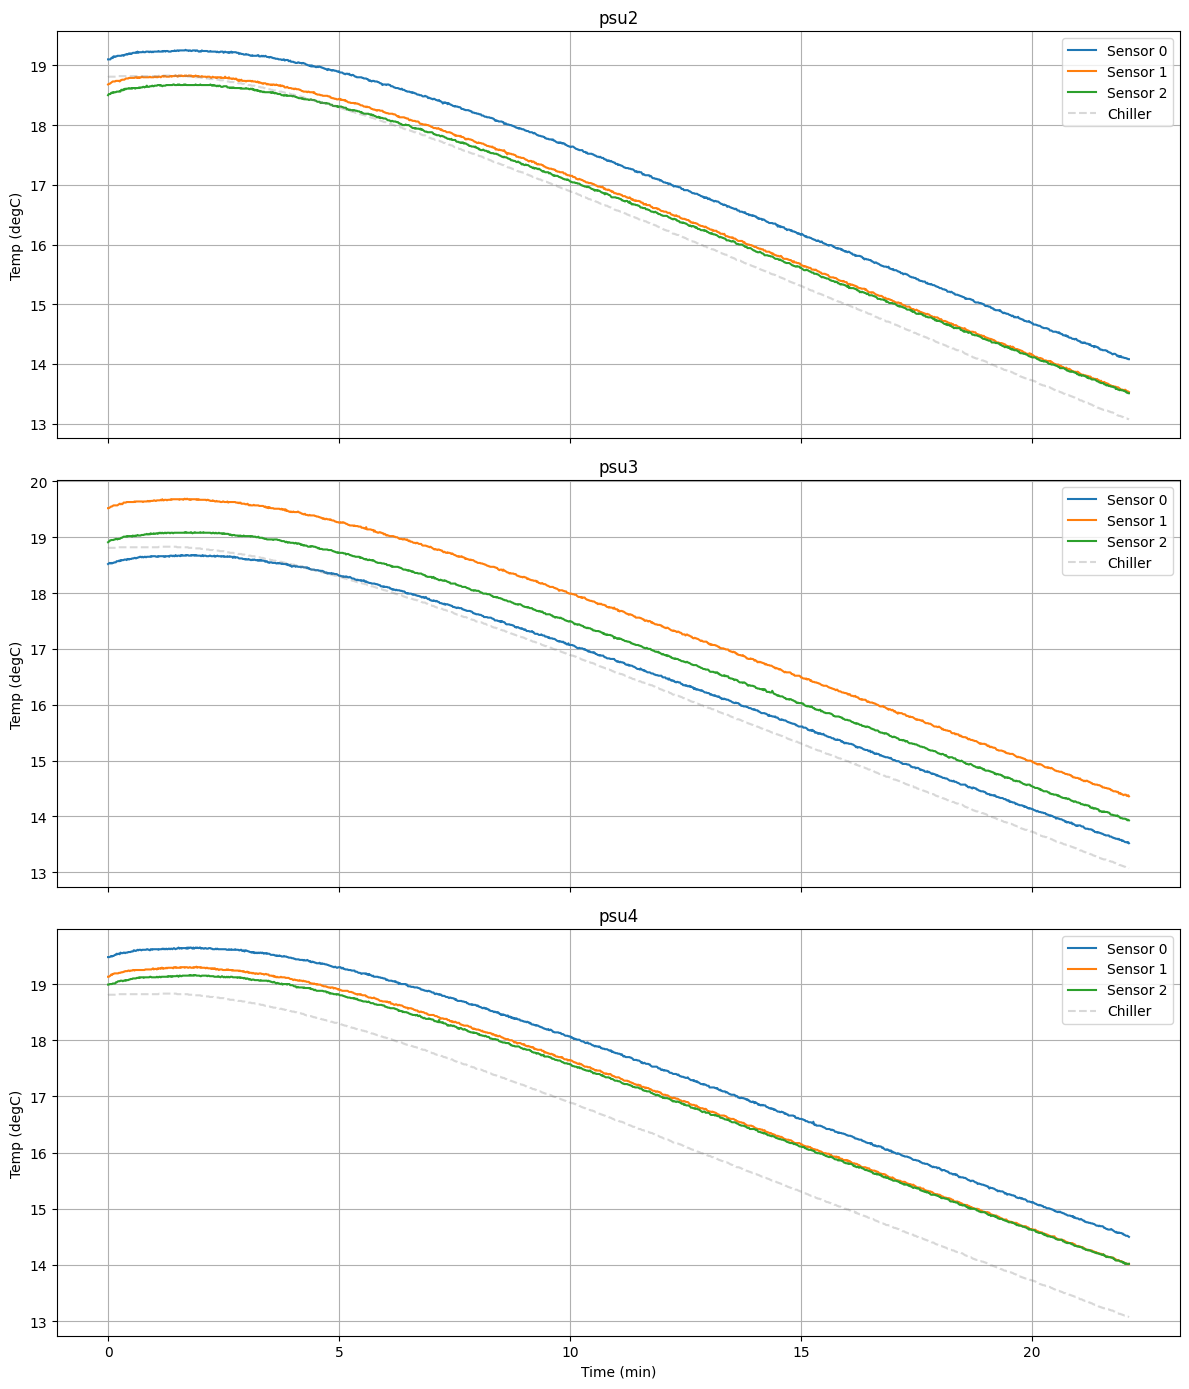

In [24]:
import matplotlib.pyplot as plt

t = (np.array(timestamps) - timestamps[0]) / 60  # minutes
arr_chiller = np.array(data["chiller"])

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 14))

# PSU 2-4
for ax, name in zip(axes[:4], ["psu2", "psu3", "psu4"]):
    arr = np.array(data[name])
    ax.plot(t, arr[:, 0], label="Sensor 0")
    ax.plot(t, arr[:, 1], label="Sensor 1")
    ax.plot(t, arr[:, 2], label="Sensor 2")
    ax.plot(t, arr_chiller, label="Chiller", alpha=0.3, color="gray", linestyle="--")
    ax.set_ylabel("Temp (degC)")
    ax.set_title(name)
    ax.legend(loc="upper right")
    ax.grid(True)

axes[2].set_xlabel("Time (min)")
fig.tight_layout()
plt.savefig(log_dir / f"016_Temp_Plot_{timestamp}.png", dpi=150)
plt.show()

## Stop Chiller and Disconnect

In [25]:
chiller.stop_device()

In [ ]:
chiller.set_temperature(18.0)

In [26]:
#psu1.disconnect()
psu2.disconnect()
psu3.disconnect()
psu4.disconnect()
#swA.disconnect()
#swB.disconnect()

2026-03-25 15:22:21,590 - INFO - psu2 - Disconnecting PSU device psu2
2026-03-25 15:22:21,603 - INFO - psu2 - Successfully disconnected PSU device psu2
2026-03-25 15:22:21,603 - INFO - psu3 - Disconnecting PSU device psu3
2026-03-25 15:22:21,618 - INFO - psu3 - Successfully disconnected PSU device psu3
2026-03-25 15:22:21,618 - INFO - psu4 - Disconnecting PSU device psu4
2026-03-25 15:22:21,633 - INFO - psu4 - Successfully disconnected PSU device psu4


True

In [27]:
chiller.disconnect()

2026-03-25 15:22:22,451 - INFO - Disconnected from chiller cgc_chiller


True